In [1]:
# 0,1: 00 for psi_1, 01 for psi_2 ...
# 2,3: For states
# 4,5: Ancillary qubits

In [2]:
from qiskit import QuantumCircuit
from numpy import sqrt
from qiskit.circuit.library import StatePreparation
def circuit_init():
    qc = QuantumCircuit(6)
    return qc

def PREP(qc):
    desired_vector = [
        1/sqrt(3), 0, 0, 0, 
        1/(4*sqrt(3)), 1/4, 1/4, sqrt(3)/4, 
        1/(4*sqrt(3)), -1/4, -1/4, sqrt(3)/4, 
        0, 0, 0, 0
    ]
    prep = StatePreparation(desired_vector)
    qc.append(prep,[3,2,1,0])
    return qc

In [3]:
from qiskit.circuit.library.standard_gates import RXGate,RYGate, RZGate
from qiskit.circuit.library import U3Gate
from qiskit.circuit.library import MCXGate
from qiskit.circuit.library.standard_gates import XGate
from pennylane.templates.state_preparations.mottonen import compute_theta, gray_code
from numpy import array, log2


def UU(qc, wires, params):
    qc.append(U3Gate(params[0],params[1],params[2]),[wires[0]])
    qc.append(U3Gate(params[3],params[4],params[5]),[wires[1]])


def RR_Z(qc, wires, params):
    qc.append(RZGate(params[0]),[wires[0]])
    qc.append(RZGate(params[1]),[wires[1]])

def CUU(qc,wires, params, state='1'):
    qc.append(U3Gate(params[0],params[1],params[2]).control(1,ctrl_state = state[::-1]), [wires[0], wires[1]])  # Control: wires[0] Target: wires[1]
    qc.append(U3Gate(params[3],params[4],params[5]).control(1,ctrl_state = state[::-1]), [wires[0], wires[2]])  # Control: wires[0] Target: wires[2]
    return qc

def CRR_Z(qc,wires, params, state='1'):
    qc.append(RZGate(params[0]).control(1,ctrl_state = state[::-1]), [wires[0], wires[1]])  # Control: wires[0] Target: wires[1]
    qc.append(RZGate(params[1]).control(1,ctrl_state = state[::-1]), [wires[0], wires[2]])  # Control: wires[0] Target: wires[2]
    return qc

def CR_Y(qc, wires, params, state = '1'):
    qc.append(RYGate(params[0]).control(1,ctrl_state = state[::-1]), [wires[0], wires[1]])  # Control: wires[0] Target: wires[1]


def CCUU(qc,wires, params, state='11'):
    qc.append(U3Gate(params[0],params[1],params[2]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[2]])  # Control: wires[0] wires[1]
    qc.append(U3Gate(params[3],params[4],params[5]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[3]])  # Control: wires[0] wires[1]

def CCRR_Z(qc, wires, params, state = '11'):
    qc.append(RZGate(params[0]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[2]])  # Control: wires[0] wires[1]
    qc.append(RZGate(params[1]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[3]])  # Control: wires[0] wires[1]
    return qc
    

def CCR_Y(qc, wires, params, state = '11'):
    qc.append(RYGate(params[0]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[2]])  # Control: wires[0] wires[1]
    return qc

def U_CCR_decom(qc,wires,params):
    # Make sure that control qubits should be increasing order
    params = array(params)
    params = compute_theta(params) #can be on/off

    num_Ucontrols = len(wires)-1
    code = gray_code(2)
    n_selections = len(code)
    control_order = [int(log2(int(code[i], 2) ^ int(code[(i + 1) % n_selections], 2))) for i in range(n_selections)]

    for i in range(n_selections):
        qc.ry(params[i],wires[2])
        qc.cx(wires[num_Ucontrols-1 - control_order[i]],wires[2])
    
    return qc

def U_CCcR_decom(qc,wires,params):
    # Make sure that control qubits should be increasing order
    params = array(params)
    params = compute_theta(params) #can be on/off

    num_Ucontrols = len(wires)-2
    code = gray_code(2)
    n_selections = len(code)
    control_order = [int(log2(int(code[i], 2) ^ int(code[(i + 1) % n_selections], 2))) for i in range(n_selections)]

    for i in range(n_selections):
        qc.cry(params[i],wires[2],wires[3])
        CCX(qc,[wires[num_Ucontrols-1 - control_order[i]],wires[2],wires[3]],'11')
    
    return qc

def CCX(qc, wires, state = '11'):
    mcx_gate = MCXGate(num_ctrl_qubits=2,ctrl_state=state[::-1])
    qc.append(mcx_gate, [wires[0], wires[1],wires[2]])
    return qc

def CCCX(qc, wires, state = '111'):
    mcx_gate = MCXGate(num_ctrl_qubits=3,ctrl_state=state[::-1])
    qc.append(mcx_gate, [wires[0], wires[1],wires[2], wires[3]])
    return qc

def CX01(qc, wires):
    qc.append(XGate().control(1, ctrl_state='1'),[wires[0], wires[1]])
    return qc


In [4]:
from qiskit.circuit.library.standard_gates import RYGate

from numpy import pi 
def Ansatz(qc, wires, params):


    UU(qc,wires[0:2],params[0:6])
    qc.cx(wires[1],wires[0])
    RR_Z(qc,wires[0:2],params[6:8])
    qc.cx(wires[0],wires[1])
    qc.ry(params[8],wires[1])
    qc.cx(wires[1],wires[0])
    UU(qc,wires[0:2],params[9:15])

    qc.barrier()
    #Module 1
    U_CCR_decom(qc,wires[0:3],params[15:19])

    CUU(qc,[wires[2],wires[0],wires[1]],params[19:25],'0')
    CCX(qc,[wires[1],wires[2], wires[0]],'10')
    CRR_Z(qc,[wires[2],wires[0],wires[1]],params[25:27],'0')
    CCX(qc,[wires[0],wires[2], wires[1]],'10')
    CR_Y(qc,[wires[2], wires[1]],[params[27]],'0')
    CCX(qc,[wires[1],wires[2], wires[0]],'10')
    CUU(qc,[wires[2],wires[0],wires[1]],params[28:34],'0')
    
    CUU(qc,[wires[2],wires[0],wires[1]],params[34:40],'1')
    CCX(qc,[wires[1],wires[2], wires[0]],'11')
    CRR_Z(qc,[wires[2],wires[0],wires[1]],params[40:42],'1')
    CCX(qc,[wires[0],wires[2], wires[1]],'11')
    CR_Y(qc,[wires[2], wires[1]],[params[42]],'1')
    CCX(qc,[wires[1],wires[2], wires[0]],'11')
    CUU(qc,[wires[2],wires[0],wires[1]],params[43:49],'1')

    qc.barrier()
    #Module 2
    U_CCcR_decom(qc, wires[0:4],params[49:53])
    CCUU(qc,[wires[2],wires[3],wires[0],wires[1]],params[53:59],'10')
    CCCX(qc,[wires[1],wires[2],wires[3],wires[0]],'110')
    CCRR_Z(qc,[wires[2],wires[3],wires[0],wires[1]], params[59:61], '10')
    CCCX(qc,[wires[0],wires[2],wires[3],wires[1]],'110')
    CCR_Y(qc,[wires[2],wires[3],wires[1]],[params[61]],'10')
    CCCX(qc,[wires[1],wires[2],wires[3],wires[0]],'110')
    CCUU(qc,[wires[2],wires[3],wires[0],wires[1]],params[62:68],'10')
    
    CCUU(qc,[wires[2],wires[3],wires[0],wires[1]],params[68:74],'11')
    CCCX(qc,[wires[1],wires[2],wires[3],wires[0]],'111')
    CCRR_Z(qc,[wires[2],wires[3],wires[0],wires[1]], params[74:76], '11')
    CCCX(qc,[wires[0],wires[2],wires[3],wires[1]],'111')
    CCR_Y(qc,[wires[2],wires[3],wires[1]],[params[76]],'11')
    CCCX(qc,[wires[1],wires[2],wires[3],wires[0]],'111')
    CCUU(qc,[wires[2],wires[3],wires[0],wires[1]],params[77:83],'11')
    
    CX01(qc, [wires[3],wires[2]])
    qc.measure_all()
    return qc

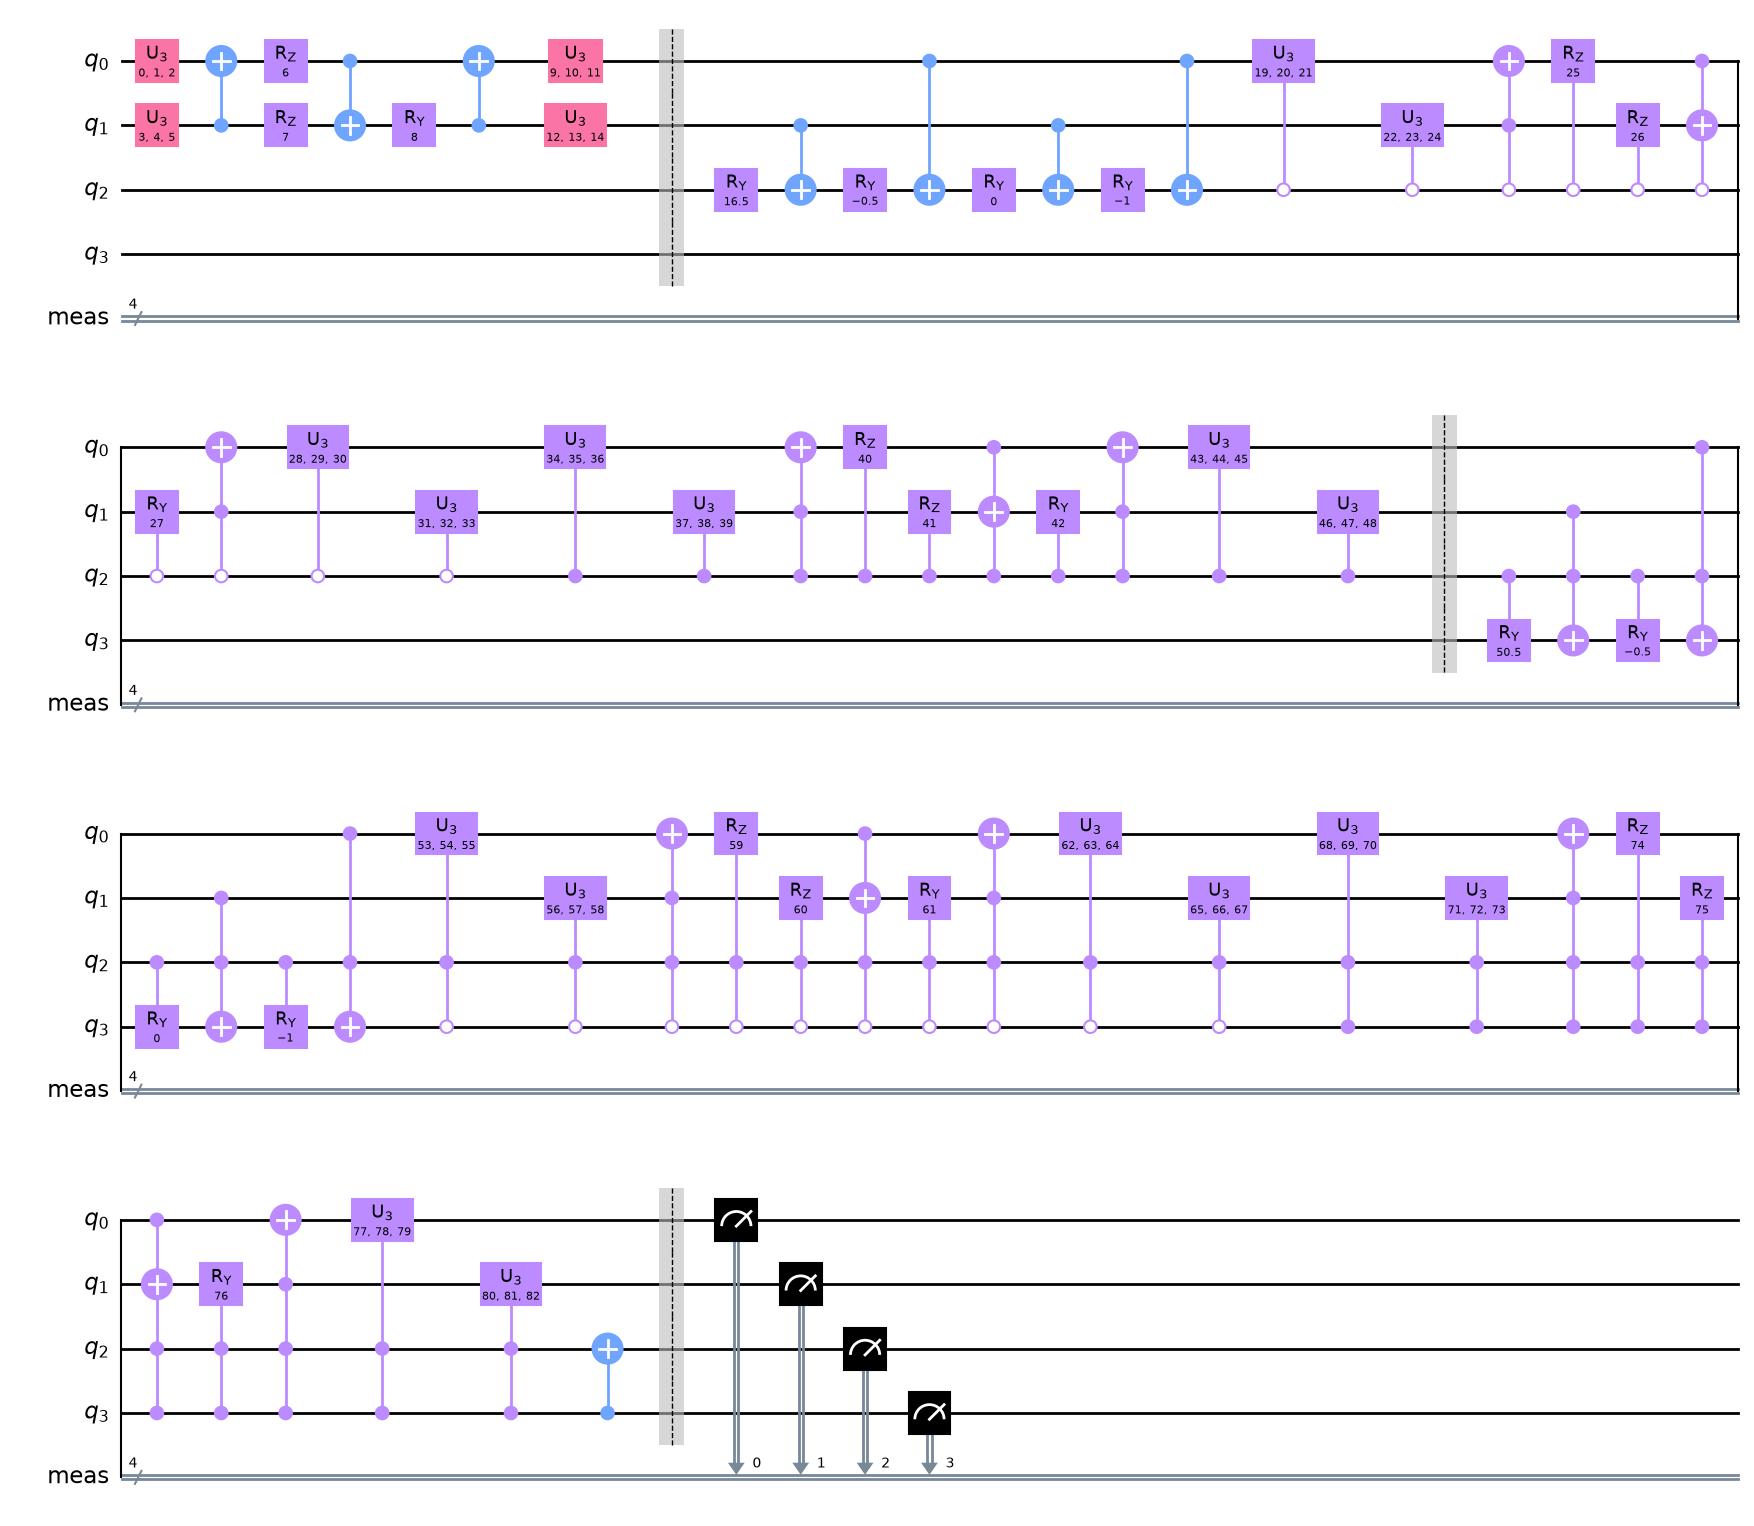

In [5]:
from numpy.random import rand
num_params=83
params = list(range(num_params))
qc = QuantumCircuit(4)
#PREP(qc)
Ansatz(qc, [0,1,2,3] , params)
qc.draw(output='mpl', style = 'clifford') 

In [6]:
# ============================================================
# AWS Braket / IQM Garnet Setup
# ============================================================

from braket.aws import AwsDevice
from qiskit_braket_provider import BraketProvider
from qiskit import transpile
import numpy as np


GARNET_ARN = (
    "arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet"
)


# ============================================================
# Check IQM Garnet
# ============================================================

garnet_device = AwsDevice(
    GARNET_ARN
)


print(
    "Device name   :",
    garnet_device.name
)


print(
    "Device status :",
    garnet_device.status
)


try:

    qd = garnet_device.queue_depth()


    print(
        "Quantum-task queue :",
        qd.quantum_tasks
    )


    print(
        "Hybrid-job queue   :",
        qd.jobs
    )


except Exception as exc:

    print(
        "Queue depth unavailable:",
        exc
    )


# ============================================================
# Qiskit-Braket Backend
# ============================================================

provider = BraketProvider()


garnet_backend = provider.get_backend(
    "Garnet"
)


print(
    "Qiskit-Braket backend:",
    garnet_backend
)


# ============================================================
# Hardware Safety Switch
# ============================================================

HARDWARE_RUN = True


# ============================================================
# IQM Garnet Circuit Resource Report
# ============================================================

def circuit_resource_report(
    qc,
    backend,
    optimization_level=3,
    seed_transpiler=150
):

    tqc = transpile(
        qc,
        backend=backend,
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler
    )


    op_counts = dict(
        tqc.count_ops()
    )


    one_q = 0
    two_q = 0
    multi_q = 0
    measurements = 0


    for item in tqc.data:

        name = item.operation.name

        nq = len(
            item.qubits
        )


        if name == "measure":

            measurements += 1


        elif nq == 1:

            one_q += 1


        elif nq == 2:

            two_q += 1


        elif nq > 2:

            multi_q += 1


    metrics = {

        "num_qubits":
            tqc.num_qubits,

        "depth":
            tqc.depth(),

        "size":
            tqc.size(),

        "1q_gate_count":
            one_q,

        "2q_gate_count":
            two_q,

        "multiq_gate_count":
            multi_q,

        "measurement_count":
            measurements,

        "cz_count":
            int(
                op_counts.get(
                    "cz",
                    0
                )
            ),

        "cx_count":
            int(
                op_counts.get(
                    "cx",
                    0
                )
            ),

        "operation_counts":
            op_counts,
    }


    print(
        "\n=== IQM Garnet Transpiled Resource Report ==="
    )


    for key, value in metrics.items():

        print(
            f"{key:22s}: {value}"
        )


    return tqc, metrics

Device name   : Garnet
Device status : ONLINE
Quantum-task queue : {<QueueType.NORMAL: 'Normal'>: '0', <QueueType.PRIORITY: 'Priority'>: '0'}
Hybrid-job queue   : 0
Qiskit-Braket backend: BraketBackend[Garnet]


In [7]:
# ============================================================
# Representative Circuit Resource Check
# ============================================================
# This does NOT submit a QPU task.
#
# DT Naimark UCdecom:
#   total parameters = 83
#
# Random parameters prevent accidental simplification of
# rotation gates during transpilation.
# ============================================================

num_params = 83


RESOURCE_SEED = 150


resource_rng = np.random.default_rng(
    RESOURCE_SEED
)


resource_params = resource_rng.random(
    num_params
)


print(
    "\nResource-check random parameters:"
)


print(
    np.array2string(
        resource_params,
        precision=10,
        separator=", "
    )
)


qc_resource = circuit_init()


PREP(
    qc_resource
)


Ansatz(
    qc_resource,
    [2, 3, 4, 5],
    resource_params
)


qc_resource = (
    qc_resource.reverse_bits()
)


garnet_transpiled_example, garnet_resource_metrics = (
    circuit_resource_report(

        qc_resource,

        garnet_backend,

        optimization_level=3,

        seed_transpiler=RESOURCE_SEED
    )
)


Resource-check random parameters:
[0.0048220441, 0.9307870177, 0.784582211 , 0.3343249593, 0.6862689177,
 0.7322625609, 0.8246472415, 0.1074544391, 0.3089916869, 0.3129434404,
 0.5940727125, 0.6105506387, 0.9165420506, 0.7388171743, 0.3774708002,
 0.7949533184, 0.4869354822, 0.5788914075, 0.9744748566, 0.6883896757,
 0.5848087428, 0.2739643248, 0.8377858251, 0.3022293541, 0.1728462164,
 0.8017433668, 0.3441099205, 0.4375847094, 0.152681156 , 0.2761357842,
 0.5638672039, 0.8646746614, 0.0827886029, 0.9748236223, 0.9228236344,
 0.4073736921, 0.7807688858, 0.6465955762, 0.2254609107, 0.8244806881,
 0.3453562772, 0.5685671364, 0.6863696968, 0.2470087963, 0.8753744063,
 0.1559330851, 0.6952022537, 0.165220456 , 0.4809662579, 0.5220324731,
 0.574713288 , 0.8415277736, 0.4884155772, 0.9164990051, 0.1245572572,
 0.4537852901, 0.9589130366, 0.6706482599, 0.7928513073, 0.7638068903,
 0.4694302963, 0.2684748849, 0.4532232777, 0.2527348132, 0.9472151713,
 0.0497407763, 0.4375196366, 0.7683879889,

In [8]:
from scipy.optimize import minimize

import numpy as np
import os
import time


# ============================================================
# Settings
# ============================================================

num_times = 3

num_shots = 1000


optimizer_name = "COBYLA"

tol_value = 0.01

maxiter = 150


BASE_SEED = 150


num_params = 83


report_filename = (
    "DT_Naimark_UCdecom_IQM_Garnet_report.txt"
)


# ============================================================
# High-Shot Evaluation Settings
# ============================================================

evaluation_num_times = 5

evaluation_num_shots = 5000


EVALUATION_BASE_SEED = 10000


evaluation_seeds = np.array(
    [
        EVALUATION_BASE_SEED + i
        for i in range(
            evaluation_num_times
        )
    ],
    dtype=int
)


# ============================================================
# Storage
# ============================================================

final_optimized_values = []


initial_params_all_runs = []

optimal_params_all_runs = []


optimization_success_all_runs = []

optimization_status_all_runs = []

optimization_message_all_runs = []

optimization_nfev_all_runs = []

reached_maxiter_all_runs = []


# ------------------------------------------------------------
# Runtime Storage
# ------------------------------------------------------------

optimization_wall_times = []


# ------------------------------------------------------------
# IQM Garnet QPU Usage Storage
# ------------------------------------------------------------

garnet_task_count = 0

garnet_total_shots = 0

garnet_task_ids = []


# ------------------------------------------------------------
# High-Shot Evaluation Storage
# ------------------------------------------------------------

evaluation_values_all_runs = []


evaluation_mean_all_runs = []

evaluation_std_all_runs = []


evaluation_min_all_runs = []

evaluation_max_all_runs = []

In [9]:
# ============================================================
# Objective Function
# ============================================================

def objective_function(
    params,
    run_seed,
    shots=None,
    print_result=True
):

    global garnet_task_count
    global garnet_total_shots
    global garnet_task_ids


    if shots is None:

        shots = num_shots


    # ========================================================
    # Construct Circuit
    # ========================================================

    qc = circuit_init()


    PREP(
        qc
    )


    Ansatz(
        qc,
        [2, 3, 4, 5],
        params
    )


    qc_reverse = (
        qc.reverse_bits()
    )


    # ========================================================
    # Transpile for IQM Garnet
    # ========================================================

    t_qc = transpile(
        qc_reverse,
        backend=garnet_backend,
        optimization_level=3,
        seed_transpiler=run_seed
    )


    # ========================================================
    # Hardware Safety Check
    # ========================================================

    if not HARDWARE_RUN:

        raise RuntimeError(
            "HARDWARE_RUN is False. "
            "QPU submission has been disabled."
        )


    # ========================================================
    # Submit to IQM Garnet
    # ========================================================

    job = garnet_backend.run(
        t_qc,
        shots=shots,
        verbatim=True
    )


    # ========================================================
    # Garnet Usage Accounting
    # ========================================================

    garnet_task_count += 1

    garnet_total_shots += int(
        shots
    )


    try:

        task_id = job.job_id()


        garnet_task_ids.append(
            task_id
        )


        if print_result:

            print(
                "Braket task ID:",
                task_id
            )


    except Exception:

        pass


    # ========================================================
    # Get Result
    # ========================================================

    result = job.result()


    counts = result.get_counts()


    # ========================================================
    # Target Counts
    # ========================================================
    #
    # DT Naimark UCdecom is a 6-qubit circuit.
    # Keep the original [4:6] indexing.
    # ========================================================

    tar_00 = 0

    tar_01 = 0

    tar_10 = 0


    for outcome, count in counts.items():


        if outcome[0:2] == "00":

            if outcome[4:6] == "00":

                tar_00 += count


        if outcome[0:2] == "01":

            if outcome[4:6] == "01":

                tar_01 += count


        if outcome[0:2] == "10":

            if outcome[4:6] == "10":

                tar_10 += count


    # ========================================================
    # Success Probability
    # ========================================================

    p_suc = (
        tar_00
        + tar_01
        + tar_10
    ) / shots


    if print_result:

        print(
            f"success_probability = "
            f"{p_suc:.8f}"
        )


    # ========================================================
    # Avoid Division by Zero
    # ========================================================

    if p_suc == 0:

        return 1e10


    # ========================================================
    # COBYLA minimizes.
    #
    # Minimize 1 / p_suc to maximize p_suc.
    # ========================================================

    return 1.0 / p_suc

In [10]:
# ============================================================
# Optimization + High-Shot Evaluation + Statistics + Report
# ============================================================

total_wall_start = time.perf_counter()


# ============================================================
# Run Optimization
# ============================================================

for run in range(
    num_times
):


    # ========================================================
    # Optimization Seed
    # ========================================================

    run_seed = (
        BASE_SEED + run
    )


    rng = np.random.default_rng(
        run_seed
    )


    print(
        "\n"
        + "=" * 80
    )


    print(
        f"Optimization Run "
        f"{run + 1}/{num_times}"
    )


    print(
        f"Optimization Seed : "
        f"{run_seed}"
    )


    print(
        "=" * 80
    )


    # ========================================================
    # Random Initial Parameters
    # ========================================================

    initial_params = rng.random(
        num_params
    )


    initial_params_all_runs.append(
        initial_params.copy()
    )


    print(
        "\nInitial Parameters:"
    )


    print(
        np.array2string(
            initial_params,
            precision=10,
            separator=", "
        )
    )


    # ========================================================
    # COBYLA Optimization
    # ========================================================

    print(
        "\nStarting COBYLA optimization..."
    )


    optimization_start = (
        time.perf_counter()
    )


    result = minimize(

        fun=lambda params: objective_function(
            params,
            run_seed,
            shots=num_shots,
            print_result=True
        ),

        x0=initial_params,

        method=optimizer_name,

        options={
            "maxiter": maxiter,
            "disp": True,
            "tol": tol_value
        }
    )


    optimization_end = (
        time.perf_counter()
    )


    run_optimization_wall_time = (
        optimization_end
        - optimization_start
    )


    optimization_wall_times.append(
        run_optimization_wall_time
    )


    # ========================================================
    # Optimization Status
    # ========================================================

    optimization_success = bool(
        result.success
    )


    optimization_status = getattr(
        result,
        "status",
        None
    )


    optimization_message = str(
        getattr(
            result,
            "message",
            "No message returned"
        )
    )


    optimization_nfev = getattr(
        result,
        "nfev",
        None
    )


    message_lower = (
        optimization_message.lower()
    )


    reached_maxiter = (

        "maximum number"
        in message_lower

        or "maximum function"
        in message_lower

        or "maxiter"
        in message_lower

        or "maxfun"
        in message_lower

        or "maximum iterations"
        in message_lower

        or "maximum evaluations"
        in message_lower
    )


    if optimization_nfev is not None:

        if optimization_nfev >= maxiter:

            reached_maxiter = True


    optimization_success_all_runs.append(
        optimization_success
    )


    optimization_status_all_runs.append(
        optimization_status
    )


    optimization_message_all_runs.append(
        optimization_message
    )


    optimization_nfev_all_runs.append(
        optimization_nfev
    )


    reached_maxiter_all_runs.append(
        reached_maxiter
    )


    # ========================================================
    # Optimal Parameters
    # ========================================================

    optimal_params = (
        result.x.copy()
    )


    optimal_params_all_runs.append(
        optimal_params.copy()
    )


    # ========================================================
    # Final Optimization-Shot Evaluation
    # ========================================================

    final_objective = objective_function(
        optimal_params,
        run_seed,
        shots=num_shots,
        print_result=False
    )


    if final_objective >= 1e10:

        final_value = 0.0

    else:

        final_value = (
            1.0 / final_objective
        )


    final_optimized_values.append(
        final_value
    )


    # ========================================================
    # High-Shot Evaluation
    # ========================================================

    print(
        "\n"
        + "-" * 80
    )


    print(
        "HIGH-SHOT EVALUATION OF "
        "OPTIMIZED PARAMETERS"
    )


    print(
        "-" * 80
    )


    print(
        f"Optimization Shots     : "
        f"{num_shots}"
    )


    print(
        f"Evaluation Shots       : "
        f"{evaluation_num_shots}"
    )


    print(
        f"Number of Evaluations : "
        f"{evaluation_num_times}"
    )


    print(
        "\nEvaluation Results:"
    )


    evaluation_values = []


    for eval_index, eval_seed in enumerate(
        evaluation_seeds
    ):


        eval_objective = objective_function(
            optimal_params,
            int(eval_seed),
            shots=evaluation_num_shots,
            print_result=False
        )


        if eval_objective >= 1e10:

            eval_value = 0.0

        else:

            eval_value = (
                1.0 / eval_objective
            )


        evaluation_values.append(
            eval_value
        )


        print(
            f"Evaluation "
            f"{eval_index + 1:2d}/"
            f"{evaluation_num_times:2d}"
            f" | Value = "
            f"{eval_value:.8f}"
        )


    # ========================================================
    # Evaluation Statistics
    # ========================================================

    evaluation_values = np.array(
        evaluation_values,
        dtype=float
    )


    evaluation_mean = np.mean(
        evaluation_values
    )


    evaluation_std = np.std(
        evaluation_values
    )


    evaluation_min = np.min(
        evaluation_values
    )


    evaluation_max = np.max(
        evaluation_values
    )


    evaluation_values_all_runs.append(
        evaluation_values.copy()
    )


    evaluation_mean_all_runs.append(
        evaluation_mean
    )


    evaluation_std_all_runs.append(
        evaluation_std
    )


    evaluation_min_all_runs.append(
        evaluation_min
    )


    evaluation_max_all_runs.append(
        evaluation_max
    )


    # ========================================================
    # Individual Run Report
    # ========================================================

    print(
        "\n"
        + "=" * 80
    )


    print(
        f"RUN {run + 1} RESULT"
    )


    print(
        "=" * 80
    )


    print(
        f"Optimization Success : "
        f"{optimization_success}"
    )


    print(
        f"Reached MaxIter      : "
        f"{reached_maxiter}"
    )


    print(
        f"Status               : "
        f"{optimization_status}"
    )


    print(
        f"Message              : "
        f"{optimization_message}"
    )


    print(
        f"Function Evaluations : "
        f"{optimization_nfev}"
    )


    print(
        f"Optimization Time    : "
        f"{run_optimization_wall_time:.6f} s"
    )


    print(
        f"Final Objective Value: "
        f"{result.fun}"
    )


    print(
        "\n"
        + "-" * 80
    )


    print(
        "OPTIMIZED AND HIGH-SHOT "
        "EVALUATED VALUES"
    )


    print(
        "-" * 80
    )


    print(
        f"Final Optimized Value : "
        f"{final_value:.8f}"
    )


    print(
        f"Evaluated Mean        : "
        f"{evaluation_mean:.8f}"
    )


    print(
        f"Evaluated Std         : "
        f"{evaluation_std:.8f}"
    )


    print(
        f"Evaluated Min         : "
        f"{evaluation_min:.8f}"
    )


    print(
        f"Evaluated Max         : "
        f"{evaluation_max:.8f}"
    )


    print(
        "\nAll Evaluated Values:"
    )


    print(
        np.array2string(
            evaluation_values,
            precision=8,
            separator=", "
        )
    )


    print(
        "\nInitial Parameters:"
    )


    print(
        np.array2string(
            initial_params,
            precision=10,
            separator=", "
        )
    )


    print(
        "\nOptimal Parameters:"
    )


    print(
        np.array2string(
            optimal_params,
            precision=10,
            separator=", "
        )
    )


    print(
        "=" * 80
    )


# ============================================================
# Runtime Statistics
# ============================================================

total_wall_end = (
    time.perf_counter()
)


total_wall_time = (
    total_wall_end
    - total_wall_start
)


optimization_wall_times = np.array(
    optimization_wall_times,
    dtype=float
)


total_optimization_wall_time = np.sum(
    optimization_wall_times
)


mean_optimization_wall_time = np.mean(
    optimization_wall_times
)


std_optimization_wall_time = np.std(
    optimization_wall_times
)


# ============================================================
# Convert Results to NumPy Arrays
# ============================================================

final_optimized_values = np.array(
    final_optimized_values,
    dtype=float
)


initial_params_all_runs = np.array(
    initial_params_all_runs
)


optimal_params_all_runs = np.array(
    optimal_params_all_runs
)


evaluation_values_all_runs = np.array(
    evaluation_values_all_runs,
    dtype=float
)


evaluation_mean_all_runs = np.array(
    evaluation_mean_all_runs,
    dtype=float
)


evaluation_std_all_runs = np.array(
    evaluation_std_all_runs,
    dtype=float
)


evaluation_min_all_runs = np.array(
    evaluation_min_all_runs,
    dtype=float
)


evaluation_max_all_runs = np.array(
    evaluation_max_all_runs,
    dtype=float
)


# ============================================================
# Original Optimization Statistics
# ============================================================

maximum_value = np.max(
    final_optimized_values
)


mean_value = np.mean(
    final_optimized_values
)


std_value = np.std(
    final_optimized_values
)


maximum_run_index = np.argmax(
    final_optimized_values
)


maximum_run = (
    maximum_run_index + 1
)


# ============================================================
# High-Shot Evaluation Statistics
# ============================================================

maximum_evaluated_mean = np.max(
    evaluation_mean_all_runs
)


maximum_evaluated_mean_run_index = np.argmax(
    evaluation_mean_all_runs
)


maximum_evaluated_mean_run = (
    maximum_evaluated_mean_run_index
    + 1
)


mean_of_evaluated_means = np.mean(
    evaluation_mean_all_runs
)


std_of_evaluated_means = np.std(
    evaluation_mean_all_runs
)


# ============================================================
# Function Evaluation Statistics
# ============================================================

nfev_values = np.array(
    [
        nfev
        for nfev
        in optimization_nfev_all_runs
        if nfev is not None
    ],
    dtype=float
)


if len(
    nfev_values
) > 0:

    mean_nfev = np.mean(
        nfev_values
    )


    std_nfev = np.std(
        nfev_values
    )


else:

    mean_nfev = np.nan

    std_nfev = np.nan


# ============================================================
# Optimization Success Statistics
# ============================================================

num_successful_runs = sum(
    optimization_success_all_runs
)


num_failed_runs = (
    num_times
    - num_successful_runs
)


num_reached_maxiter = sum(
    reached_maxiter_all_runs
)


# ============================================================
# Best Runs
# ============================================================

best_initial_params = (
    initial_params_all_runs[
        maximum_run_index
    ]
)


best_optimal_params = (
    optimal_params_all_runs[
        maximum_run_index
    ]
)


best_evaluated_initial_params = (
    initial_params_all_runs[
        maximum_evaluated_mean_run_index
    ]
)


best_evaluated_optimal_params = (
    optimal_params_all_runs[
        maximum_evaluated_mean_run_index
    ]
)


best_evaluated_values = (
    evaluation_values_all_runs[
        maximum_evaluated_mean_run_index
    ]
)


# ============================================================
# Print Final Report
# ============================================================

print(
    "\n"
)


print(
    "=" * 100
)


print(
    "FINAL OPTIMIZATION AND "
    "HIGH-SHOT EVALUATION REPORT"
)


print(
    "=" * 100
)


print(
    f"Hardware                : IQM Garnet"
)


print(
    f"Hardware ARN            : {GARNET_ARN}"
)


print(
    f"Ansatz                  : DT Naimark UCdecom"
)


print(
    f"Optimizer               : {optimizer_name}"
)


print(
    f"Tolerance               : {tol_value}"
)


print(
    f"Max Iteration           : {maxiter}"
)


print(
    f"Number of Runs          : {num_times}"
)


print(
    f"Number of Parameters    : {num_params}"
)


print(
    f"Optimization Shots      : {num_shots}"
)


print(
    f"Optimization Base Seed  : {BASE_SEED}"
)


print(
    f"Evaluation Shots        : {evaluation_num_shots}"
)


print(
    f"Evaluations Per Run     : {evaluation_num_times}"
)


print(
    f"Evaluation Base Seed    : {EVALUATION_BASE_SEED}"
)


print(
    "Evaluation Seeds        : "
    + np.array2string(
        evaluation_seeds,
        separator=", "
    )
)


print(
    f"Resource Parameter Seed : {RESOURCE_SEED}"
)


print(
    "=" * 100
)


# ============================================================
# Results for Every Run
# ============================================================

for i in range(
    num_times
):


    print(
        f"\nRun {i + 1:2d}"
    )


    print(
        "-" * 100
    )


    print(
        f"Optimization Seed : "
        f"{BASE_SEED + i}"
    )


    print(
        f"Optimized Value   : "
        f"{final_optimized_values[i]:.8f}"
    )


    print(
        f"Evaluated Mean    : "
        f"{evaluation_mean_all_runs[i]:.8f}"
    )


    print(
        f"Evaluated Std     : "
        f"{evaluation_std_all_runs[i]:.8f}"
    )


    print(
        f"Evaluated Min     : "
        f"{evaluation_min_all_runs[i]:.8f}"
    )


    print(
        f"Evaluated Max     : "
        f"{evaluation_max_all_runs[i]:.8f}"
    )


    print(
        f"Success           : "
        f"{optimization_success_all_runs[i]}"
    )


    print(
        f"Reached MaxIter   : "
        f"{reached_maxiter_all_runs[i]}"
    )


    print(
        f"Status            : "
        f"{optimization_status_all_runs[i]}"
    )


    print(
        f"Message           : "
        f"{optimization_message_all_runs[i]}"
    )


    print(
        f"Function Evals    : "
        f"{optimization_nfev_all_runs[i]}"
    )


    print(
        f"Optimization Time : "
        f"{optimization_wall_times[i]:.6f} s"
    )


    print(
        "\nEvaluated Values:"
    )


    print(
        np.array2string(
            evaluation_values_all_runs[i],
            precision=8,
            separator=", "
        )
    )


    print(
        "\nInitial Parameters:"
    )


    print(
        np.array2string(
            initial_params_all_runs[i],
            precision=10,
            separator=", "
        )
    )


    print(
        "\nOptimal Parameters:"
    )


    print(
        np.array2string(
            optimal_params_all_runs[i],
            precision=10,
            separator=", "
        )
    )


    print(
        "-" * 100
    )


# ============================================================
# Summary
# ============================================================

print(
    "\nSUMMARY"
)


print(
    "=" * 100
)


print(
    "\nOriginal Optimization-Shot Results:"
)


print(
    f"Maximum Optimized Value : "
    f"{maximum_value:.8f}"
)


print(
    f"Maximum Run             : "
    f"{maximum_run}"
)


print(
    f"Mean Optimized Value    : "
    f"{mean_value:.8f}"
)


print(
    f"Std Optimized Value     : "
    f"{std_value:.8f}"
)


print(
    "\nHigh-Shot Evaluation Results:"
)


print(
    f"Best Evaluated Mean     : "
    f"{maximum_evaluated_mean:.8f}"
)


print(
    f"Best Evaluated Mean Run : "
    f"{maximum_evaluated_mean_run}"
)


print(
    f"Mean of Evaluated Means : "
    f"{mean_of_evaluated_means:.8f}"
)


print(
    f"Std of Evaluated Means  : "
    f"{std_of_evaluated_means:.8f}"
)


print(
    "\nOptimizer Statistics:"
)


print(
    f"Mean Function Evals     : "
    f"{mean_nfev:.2f}"
)


print(
    f"Std Function Evals      : "
    f"{std_nfev:.2f}"
)


print(
    f"Successful Runs         : "
    f"{num_successful_runs}/{num_times}"
)


print(
    f"Failed Runs             : "
    f"{num_failed_runs}/{num_times}"
)


print(
    f"Reached MaxIter         : "
    f"{num_reached_maxiter}/{num_times}"
)


print(
    "\nComputational Runtime Statistics:"
)


print(
    f"Total Wall-Clock Time          : "
    f"{total_wall_time:.6f} s"
)


print(
    f"Total Optimization Time        : "
    f"{total_optimization_wall_time:.6f} s"
)


print(
    f"Time per Complete Opt. Run     : "
    f"{mean_optimization_wall_time:.6f} s"
)


print(
    f"Std Optimization Time per Run  : "
    f"{std_optimization_wall_time:.6f} s"
)


# ============================================================
# Best Run According to Original Optimized Value
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "BEST RUN ACCORDING TO "
    "ORIGINAL OPTIMIZED VALUE"
)


print(
    "=" * 100
)


print(
    f"Run             : "
    f"{maximum_run}"
)


print(
    f"Optimized Value : "
    f"{final_optimized_values[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Mean  : "
    f"{evaluation_mean_all_runs[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Std   : "
    f"{evaluation_std_all_runs[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Min   : "
    f"{evaluation_min_all_runs[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Max   : "
    f"{evaluation_max_all_runs[maximum_run_index]:.8f}"
)


print(
    "\nEvaluated Values:"
)


print(
    np.array2string(
        evaluation_values_all_runs[
            maximum_run_index
        ],
        precision=8,
        separator=", "
    )
)


print(
    "\nInitial Parameters:"
)


print(
    np.array2string(
        best_initial_params,
        precision=10,
        separator=", "
    )
)


print(
    "\nOptimal Parameters:"
)


print(
    np.array2string(
        best_optimal_params,
        precision=10,
        separator=", "
    )
)


# ============================================================
# Best Run According to High-Shot Evaluated Mean
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "BEST RUN ACCORDING TO "
    "HIGH-SHOT EVALUATED MEAN"
)


print(
    "=" * 100
)


print(
    f"Run             : "
    f"{maximum_evaluated_mean_run}"
)


print(
    f"Optimized Value : "
    f"{final_optimized_values[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Mean  : "
    f"{evaluation_mean_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Std   : "
    f"{evaluation_std_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Min   : "
    f"{evaluation_min_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Max   : "
    f"{evaluation_max_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    "\nEvaluated Values:"
)


print(
    np.array2string(
        best_evaluated_values,
        precision=8,
        separator=", "
    )
)


print(
    "\nInitial Parameters:"
)


print(
    np.array2string(
        best_evaluated_initial_params,
        precision=10,
        separator=", "
    )
)


print(
    "\nOptimal Parameters:"
)


print(
    np.array2string(
        best_evaluated_optimal_params,
        precision=10,
        separator=", "
    )
)


# ============================================================
# IQM Garnet QPU Usage Summary
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "IQM GARNET QPU USAGE SUMMARY"
)


print(
    "=" * 100
)


print(
    f"Total QPU Tasks Submitted : "
    f"{garnet_task_count}"
)


print(
    f"Total QPU Shots Submitted : "
    f"{garnet_total_shots}"
)


print(
    "\nBraket Task IDs:"
)


for i, task_id in enumerate(
    garnet_task_ids,
    start=1
):

    print(
        f"{i:4d}: {task_id}"
    )


print(
    "\nRepresentative Transpiled "
    "Circuit Resources:"
)


for key, value in garnet_resource_metrics.items():

    print(
        f"{key:22s}: {value}"
    )


# ============================================================
# Save Report to TXT
# ============================================================

with open(
    report_filename,
    "w"
) as f:


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "FINAL OPTIMIZATION AND "
        "HIGH-SHOT EVALUATION REPORT\n"
    )


    f.write(
        "=" * 100
        + "\n\n"
    )


    # ========================================================
    # Settings
    # ========================================================

    f.write(
        f"Hardware                : "
        f"IQM Garnet\n"
    )


    f.write(
        f"Hardware ARN            : "
        f"{GARNET_ARN}\n"
    )


    f.write(
        f"Ansatz                  : "
        f"DT Naimark UCdecom\n"
    )


    f.write(
        f"Optimizer               : "
        f"{optimizer_name}\n"
    )


    f.write(
        f"Tolerance               : "
        f"{tol_value}\n"
    )


    f.write(
        f"Max Iteration           : "
        f"{maxiter}\n"
    )


    f.write(
        f"Number of Runs          : "
        f"{num_times}\n"
    )


    f.write(
        f"Number of Parameters    : "
        f"{num_params}\n"
    )


    f.write(
        f"Optimization Shots      : "
        f"{num_shots}\n"
    )


    f.write(
        f"Optimization Base Seed  : "
        f"{BASE_SEED}\n"
    )


    f.write(
        f"Evaluation Shots        : "
        f"{evaluation_num_shots}\n"
    )


    f.write(
        f"Evaluations Per Run     : "
        f"{evaluation_num_times}\n"
    )


    f.write(
        f"Evaluation Base Seed    : "
        f"{EVALUATION_BASE_SEED}\n"
    )


    f.write(
        "Evaluation Seeds        : "
    )


    f.write(
        np.array2string(
            evaluation_seeds,
            separator=", "
        )
    )


    f.write(
        "\n"
    )


    f.write(
        f"Resource Parameter Seed : "
        f"{RESOURCE_SEED}\n\n"
    )


    # ========================================================
    # Results for Every Run
    # ========================================================

    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "RESULTS FOR EACH RUN\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    for i in range(
        num_times
    ):


        f.write(
            f"\nRun {i + 1:2d}\n"
        )


        f.write(
            "-" * 100
            + "\n"
        )


        f.write(
            f"Optimization Seed : "
            f"{BASE_SEED + i}\n"
        )


        f.write(
            f"Optimized Value   : "
            f"{final_optimized_values[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Mean    : "
            f"{evaluation_mean_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Std     : "
            f"{evaluation_std_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Min     : "
            f"{evaluation_min_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Max     : "
            f"{evaluation_max_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Success           : "
            f"{optimization_success_all_runs[i]}\n"
        )


        f.write(
            f"Reached MaxIter   : "
            f"{reached_maxiter_all_runs[i]}\n"
        )


        f.write(
            f"Status            : "
            f"{optimization_status_all_runs[i]}\n"
        )


        f.write(
            f"Message           : "
            f"{optimization_message_all_runs[i]}\n"
        )


        f.write(
            f"Function Evals    : "
            f"{optimization_nfev_all_runs[i]}\n"
        )


        f.write(
            f"Optimization Time : "
            f"{optimization_wall_times[i]:.6f} s\n"
        )


        f.write(
            "\nEvaluated Values:\n"
        )


        f.write(
            np.array2string(
                evaluation_values_all_runs[i],
                precision=8,
                separator=", "
            )
        )


        f.write(
            "\n\nInitial Parameters:\n"
        )


        f.write(
            np.array2string(
                initial_params_all_runs[i],
                precision=10,
                separator=", "
            )
        )


        f.write(
            "\n\nOptimal Parameters:\n"
        )


        f.write(
            np.array2string(
                optimal_params_all_runs[i],
                precision=10,
                separator=", "
            )
        )


        f.write(
            "\n"
        )


    # ========================================================
    # Summary
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )


    f.write(
        "SUMMARY\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "\nOriginal Optimization-Shot Results:\n"
    )


    f.write(
        f"Maximum Optimized Value : "
        f"{maximum_value:.8f}\n"
    )


    f.write(
        f"Maximum Run             : "
        f"{maximum_run}\n"
    )


    f.write(
        f"Mean Optimized Value    : "
        f"{mean_value:.8f}\n"
    )


    f.write(
        f"Std Optimized Value     : "
        f"{std_value:.8f}\n"
    )


    f.write(
        "\nHigh-Shot Evaluation Results:\n"
    )


    f.write(
        f"Best Evaluated Mean     : "
        f"{maximum_evaluated_mean:.8f}\n"
    )


    f.write(
        f"Best Evaluated Mean Run : "
        f"{maximum_evaluated_mean_run}\n"
    )


    f.write(
        f"Mean of Evaluated Means : "
        f"{mean_of_evaluated_means:.8f}\n"
    )


    f.write(
        f"Std of Evaluated Means  : "
        f"{std_of_evaluated_means:.8f}\n"
    )


    f.write(
        "\nOptimizer Statistics:\n"
    )


    f.write(
        f"Mean Function Evals     : "
        f"{mean_nfev:.2f}\n"
    )


    f.write(
        f"Std Function Evals      : "
        f"{std_nfev:.2f}\n"
    )


    f.write(
        f"Successful Runs         : "
        f"{num_successful_runs}/{num_times}\n"
    )


    f.write(
        f"Failed Runs             : "
        f"{num_failed_runs}/{num_times}\n"
    )


    f.write(
        f"Reached MaxIter         : "
        f"{num_reached_maxiter}/{num_times}\n"
    )


    f.write(
        "\nComputational Runtime Statistics:\n"
    )


    f.write(
        f"Total Wall-Clock Time          : "
        f"{total_wall_time:.6f} s\n"
    )


    f.write(
        f"Total Optimization Time        : "
        f"{total_optimization_wall_time:.6f} s\n"
    )


    f.write(
        f"Time per Complete Opt. Run     : "
        f"{mean_optimization_wall_time:.6f} s\n"
    )


    f.write(
        f"Std Optimization Time per Run  : "
        f"{std_optimization_wall_time:.6f} s\n"
    )


    # ========================================================
    # Best Run According to Original Optimized Value
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )


    f.write(
        "BEST RUN ACCORDING TO "
        "ORIGINAL OPTIMIZED VALUE\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Run             : "
        f"{maximum_run}\n"
    )


    f.write(
        f"Optimized Value : "
        f"{final_optimized_values[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Mean  : "
        f"{evaluation_mean_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Std   : "
        f"{evaluation_std_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Min   : "
        f"{evaluation_min_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Max   : "
        f"{evaluation_max_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        "\nEvaluated Values:\n"
    )


    f.write(
        np.array2string(
            evaluation_values_all_runs[
                maximum_run_index
            ],
            precision=8,
            separator=", "
        )
    )


    f.write(
        "\n\nInitial Parameters:\n"
    )


    f.write(
        np.array2string(
            best_initial_params,
            precision=10,
            separator=", "
        )
    )


    f.write(
        "\n\nOptimal Parameters:\n"
    )


    f.write(
        np.array2string(
            best_optimal_params,
            precision=10,
            separator=", "
        )
    )


    f.write(
        "\n"
    )


    # ========================================================
    # Best Run According to High-Shot Evaluated Mean
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )


    f.write(
        "BEST RUN ACCORDING TO "
        "HIGH-SHOT EVALUATED MEAN\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Run             : "
        f"{maximum_evaluated_mean_run}\n"
    )


    f.write(
        f"Optimized Value : "
        f"{final_optimized_values[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Mean  : "
        f"{evaluation_mean_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Std   : "
        f"{evaluation_std_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Min   : "
        f"{evaluation_min_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Max   : "
        f"{evaluation_max_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        "\nEvaluated Values:\n"
    )


    f.write(
        np.array2string(
            best_evaluated_values,
            precision=8,
            separator=", "
        )
    )


    f.write(
        "\n\nInitial Parameters:\n"
    )


    f.write(
        np.array2string(
            best_evaluated_initial_params,
            precision=10,
            separator=", "
        )
    )


    f.write(
        "\n\nOptimal Parameters:\n"
    )


    f.write(
        np.array2string(
            best_evaluated_optimal_params,
            precision=10,
            separator=", "
        )
    )


    f.write(
        "\n"
    )


    # ========================================================
    # IQM Garnet QPU Usage Summary
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )


    f.write(
        "IQM GARNET QPU USAGE SUMMARY\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Total QPU Tasks Submitted : "
        f"{garnet_task_count}\n"
    )


    f.write(
        f"Total QPU Shots Submitted : "
        f"{garnet_total_shots}\n"
    )


    f.write(
        "\nBraket Task IDs:\n"
    )


    for i, task_id in enumerate(
        garnet_task_ids,
        start=1
    ):

        f.write(
            f"{i:4d}: {task_id}\n"
        )


    f.write(
        "\nRepresentative Transpiled "
        "Circuit Resources:\n"
    )


    for key, value in garnet_resource_metrics.items():

        f.write(
            f"{key:22s}: {value}\n"
        )


# ============================================================
# Report Location
# ============================================================

print(
    "\nReport saved to:"
)


print(
    os.path.abspath(
        report_filename
    )
)


Optimization Run 1/3
Optimization Seed : 150

Initial Parameters:
[0.0048220441, 0.9307870177, 0.784582211 , 0.3343249593, 0.6862689177,
 0.7322625609, 0.8246472415, 0.1074544391, 0.3089916869, 0.3129434404,
 0.5940727125, 0.6105506387, 0.9165420506, 0.7388171743, 0.3774708002,
 0.7949533184, 0.4869354822, 0.5788914075, 0.9744748566, 0.6883896757,
 0.5848087428, 0.2739643248, 0.8377858251, 0.3022293541, 0.1728462164,
 0.8017433668, 0.3441099205, 0.4375847094, 0.152681156 , 0.2761357842,
 0.5638672039, 0.8646746614, 0.0827886029, 0.9748236223, 0.9228236344,
 0.4073736921, 0.7807688858, 0.6465955762, 0.2254609107, 0.8244806881,
 0.3453562772, 0.5685671364, 0.6863696968, 0.2470087963, 0.8753744063,
 0.1559330851, 0.6952022537, 0.165220456 , 0.4809662579, 0.5220324731,
 0.574713288 , 0.8415277736, 0.4884155772, 0.9164990051, 0.1245572572,
 0.4537852901, 0.9589130366, 0.6706482599, 0.7928513073, 0.7638068903,
 0.4694302963, 0.2684748849, 0.4532232777, 0.2527348132, 0.9472151713,
 0.0497407

/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Barrier is not included in the current Target and will be ignored.
  _translate_to_braket(
/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 3.619763141168608 will not be included in Braket circuit
  _translate_to_braket(


Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/724196a4-d553-4c6a-89e9-d55f6186e7e9
success_probability = 0.23200000


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Barrier is not included in the current Target and will be ignored.
  _translate_to_braket(
/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 0.4781704875788134 will not be included in Braket circuit
  _translate_to_braket(


Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/4329301c-d6fb-4040-bf5a-3c9a2e833d9b
success_probability = 0.22300000


...

Evaluation  3/ 5 | Value = 0.21240000


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Barrier is not included in the current Target and will be ignored.
  _translate_to_braket(
/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 5.316968251516373 will not be included in Braket circuit
  _translate_to_braket(


Evaluation  4/ 5 | Value = 0.25840000


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Barrier is not included in the current Target and will be ignored.
  _translate_to_braket(
/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 2.1753755979265677 will not be included in Braket circuit
  _translate_to_braket(


Evaluation  5/ 5 | Value = 0.23260000

RUN 3 RESULT
Optimization Success : False
Reached MaxIter      : True
Status               : 2
Message              : Maximum number of function evaluations has been exceeded.
Function Evaluations : 150
Optimization Time    : 1547.473016 s
Final Objective Value: 3.90625

--------------------------------------------------------------------------------
OPTIMIZED AND HIGH-SHOT EVALUATED VALUES
--------------------------------------------------------------------------------
Final Optimized Value : 0.20600000
Evaluated Mean        : 0.22988000
Evaluated Std         : 0.01585111
Evaluated Min         : 0.21240000
Evaluated Max         : 0.25840000

All Evaluated Values:
[0.2272, 0.2188, 0.2124, 0.2584, 0.2326]

Initial Parameters:
[0.2185327016, 0.2605845547, 0.0494520073, 0.5385992113, 0.5420706407,
 0.7890536718, 0.9123372133, 0.3722628249, 0.3257754726, 0.6556609124,
 0.8969863307, 0.6516960973, 0.7833870606, 0.8742393722, 0.1922236761,
 0.610154332 